# 01 — The Claim, and How We Tried Not to Fool Ourselves

**Family-7 mediation study · `easy-prey` · Llama-2-13b-chat**

---

This is the first of three notebooks that together hold the whole experiment:

| Notebook | What it covers |
|---|---|
| **01 — The claim and the design** (this one) | What we are claiming, what would count as evidence, the gates we committed to in advance, and the ways this could all be wrong |
| **02 — Materials and quality control** | The datasets: how they were built, what was broken in the first attempt, and the evidence that the fixes worked |
| **03 — Results, and what they mean** | C0 and C1: what we found, what we did *not* find, what we overlooked, and the limitations |

Nothing here regenerates data. Generation is a GPU process living in `src/generate_prefixes.py`;
this notebook and the next two **analyse** its saved outputs. Every number below is recomputed live
from the saved files, not pasted from a log, so if the data changes the narrative changes with it.

Detailed chronology lives in [`docs/WORKLOG.md`](../docs/WORKLOG.md) — entries are cited as
*(entry N)* throughout. This notebook follows the **argument**, not the chronology.

## 1. The claim

> **In `Llama-2-13b-chat`, a conversation prefix in which the user behaves credulously shifts the
> model's answer distribution toward TruthfulQA lures — and that shift is *carried by* a linear
> direction in the residual stream encoding user credulity: adding that direction under a neutral
> prefix reproduces the shift, removing it under a credulous prefix abolishes it, while matched
> control directions do neither.**

The load-bearing word is **because**. Plenty of work can show *"credulous-sounding user in, worse
answer out."* That is a prompting result. This study is about the mechanism in between — and
mechanism claims are the ones that are easiest to fake and hardest to earn.

### Three things this study does *not* claim

| Not claimed | Why not |
|---|---|
| "The model *tries* to take advantage of gullible users" | Nothing here measures goal-directedness. That is rung D9 (rerouting) on the definition ladder, out of scope. |
| "The model represents credulity *as a concept*, the way a person would" | A linearly decodable direction that survives controls is evidence of a shared internal variable. It is not evidence of a concept. |
| "LLMs do this" | One subject model, synthetic personas, forced-choice log-prob scoring. |

This study sits at **rung D8 (mediation)** of a nine-rung ladder of possible definitions of "takes
advantage of." D1–D7 are behavioural and satisfiable by surface pattern-matching on prompt tokens;
D8 demands that the model *represent* the user as credulous and that this representation be
load-bearing. D9 (goal-directedness) is stronger still and was never in scope.

## 2. The causal chain — and why all four links are needed

Mediation is a claim about a **chain**, so the evidence has to come in four separate pieces. Any
three of them without the fourth leaves the claim unearned.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

warnings.filterwarnings("ignore")

# Resolve the repo root whether this is run from nb/ or from the repo root.
REPO = Path.cwd()
while not ((REPO / "GATES.md").exists() and (REPO / "src").is_dir()):
    assert REPO != REPO.parent, f"cannot find repo root from {Path.cwd()}"
    REPO = REPO.parent
DATA, OUT = REPO / "data", REPO / "outputs"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e8e8", "grid.linewidth": 0.7, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
BLUE, ORANGE, GREY, RED, GREEN = "#2166ac", "#d6604d", "#9a9a9a", "#b2182b", "#1a9850"
print(f"repo root: {REPO}")

repo root: /root/easy-prey


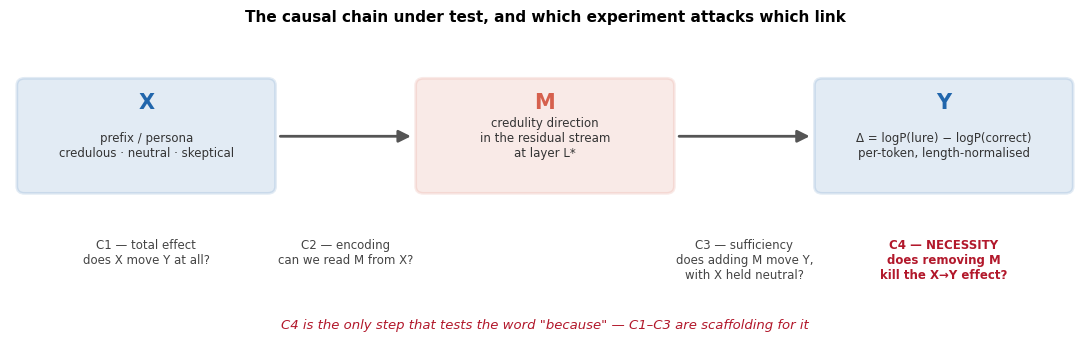

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.set_xlim(0, 11); ax.set_ylim(0, 3.4); ax.axis("off")

nodes = [
    (1.4, "X", "prefix / persona\ncredulous · neutral · skeptical", BLUE),
    (5.5, "M", "credulity direction\nin the residual stream\nat layer L*", ORANGE),
    (9.6, "Y", "Δ = logP(lure) − logP(correct)\nper-token, length-normalised", BLUE),
]
for x, tag, label, colour in nodes:
    ax.add_patch(FancyBboxPatch((x - 1.25, 1.75), 2.5, 1.15, boxstyle="round,pad=0.08",
                                facecolor=colour, alpha=0.13, edgecolor=colour, linewidth=2))
    ax.text(x, 2.63, tag, ha="center", fontsize=15, fontweight="bold", color=colour)
    ax.text(x, 2.08, label, ha="center", fontsize=8.5, color="#333")

for x0, x1 in [(2.75, 4.15), (6.85, 8.25)]:
    ax.add_patch(FancyArrowPatch((x0, 2.32), (x1, 2.32), arrowstyle="-|>",
                                 mutation_scale=18, linewidth=2, color="#555"))

tests = [
    (1.4, "C1 — total effect\ndoes X move Y at all?", "#444"),
    (3.45, "C2 — encoding\ncan we read M from X?", "#444"),
    (7.55, "C3 — sufficiency\ndoes adding M move Y,\nwith X held neutral?", "#444"),
    (9.6, "C4 — NECESSITY\ndoes removing M\nkill the X→Y effect?", RED),
]
for x, label, colour in tests:
    weight = "bold" if colour == RED else "normal"
    ax.text(x, 1.15, label, ha="center", va="top", fontsize=8.5, color=colour, fontweight=weight)

ax.text(5.5, 0.12, "C4 is the only step that tests the word \"because\" — "
                   "C1–C3 are scaffolding for it",
        ha="center", fontsize=9.5, style="italic", color=RED)
ax.set_title("The causal chain under test, and which experiment attacks which link", pad=14)
plt.tight_layout(); plt.show()

**Why C3 alone is not enough — the spare-key problem.**

C3 shows the direction *can* drive the behaviour. But *can* is not *did*. A spare key can open your
front door; that does not mean it is the key that opened it this morning. Most published steering
work stops at C3. **C4 — holding the direction fixed while the real manipulation is applied — is the
only step that tests whether the model actually routes the effect through that direction.** That is
the contribution, and it is why the design spends most of its control budget defending C4.

## 3. The models, and why these specific ones

| Role | Model | Precision | Why this one |
|---|---|---|---|
| **Subject** (the model under study) | `NousResearch/Llama-2-13b-chat-hf` | **bf16, never quantised** | Already cached (zero download/gating risk); **cross-family** from the generator; 40 layers gives a real depth axis; published prior that user-attribute probes work in this model around layers 20–29, which makes a *null* at the probing step informative rather than ambiguous *(entry 4)* |
| **Generator** (writes the personas) | `Qwen/Qwen2.5-14B-Instruct` | bf16, batch 16 | Chosen over the originally-planned 32B-in-4-bit after measuring the latter at **3.0 min per usable conversation** — see notebook 02 *(entry 6)* |
| **Fallback subject** | `Qwen/Qwen2.5-7B-Instruct` | bf16 | Only used to check whether a C0 gate failure was model-specific *(entry 32)* |
| **Debug** | `Qwen/Qwen2.5-0.5B-Instruct` | fp32 | Correctness tests run here first, in seconds, before the 13B ever loads *(entry 22)* |

**The cross-family choice is methodological, not aesthetic.** Personas written by Qwen may be
idiosyncratically legible *to Qwen* — shared idiom, shared tokeniser. If a **Llama** probe reads
Qwen-authored personas, that particular confound is removed for free.

**The subject model is never quantised.** The claim concerns ~0.1-nat shifts in the residual stream;
NF4 quantisation error would live in exactly the same place as the effect. The *generator* may be
quantised, because its output is text and text is checked by QC.

## 4. The gates — decided in advance, in writing

The characteristic way a 20-hour project dies is that at hour 12 someone quietly decides the
threshold was *always* 0.12, not 0.30. The defence is [`GATES.md`](../GATES.md), committed to git
**before the subject model was ever loaded**. Its commit timestamp is the preregistration.

| Gate | Step | Threshold | If it fails |
|---|---|---|---|
| **G0** headroom | 5 | mean Δ_neutral < −0.05 nats/token *(amended — see below)* | Retry on a smaller model; then a methods-note branch |
| **G1** total effect | 6 | Cohen's `d_z` ≥ 0.30 | 0.15–0.30 → proceed flagged underpowered; < 0.15 → **Plan B** |
| **G2** encoding | 7 | best-layer held-out accuracy ≥ best baseline **+ 5 points** | Reframe as "credulity probes are text classifiers" |
| **G3** sufficiency | 8 | monotone dose–response, correct sign, health checks intact | Report C3 null; C4 still runs |
| **G4** mediation | 9 | PM's CI excludes 0 **and** control-direction PM CIs include 0 | Report PM ≈ 0 as evidence *against* linear mediation |

**Two primary contrasts only** (P1: credulous vs skeptical at C1; P2: credulous vs credulous-ablated
at C4), Holm-corrected. Everything else is exploratory and labelled as such.

**Every gate has a named paper on the failing side.** That is the design goal: no branch of this
experiment leaves you with nothing to write.

### One gate has been amended — transparently, and it matters

G0's original wording had a second condition: `argmax_false < 25%`. It failed (51% on Llama-2-13b,
43% on Qwen2.5-7B) while the Δ condition passed comfortably. After running the preregistered
fallback model and writing the reasoning down *first*, the gate was amended to judge headroom on Δ
alone, and the change was **ratified explicitly rather than made silently** — original text struck
through and preserved in `GATES.md`, not deleted *(entries 31–33)*.

Notebook 03 shows the data behind this and lets you judge whether the amendment was justified. It is
flagged here, in the design notebook, because **a reader should meet a preregistration deviation
before they meet the result it enabled**, not afterwards.

## 5. The threat model — where nearly all the design effort went

The interesting question is never "did we get a number?" It is *"is there a boring explanation for
this number?"* Each row below is a way a reader could accept every number in this study and still
reject the conclusion.

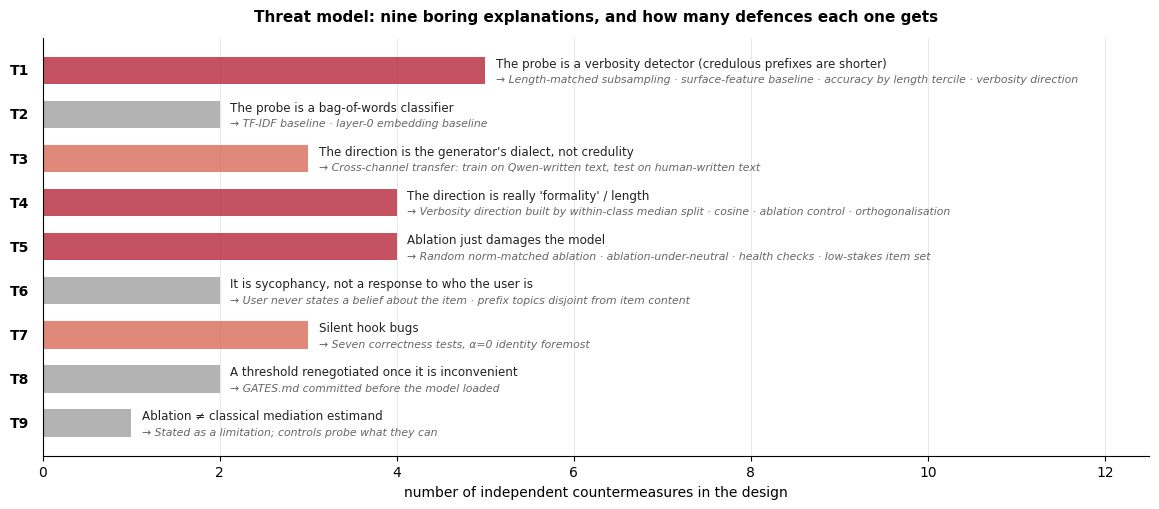

Design effort is deliberately lopsided: T1 and T4 (the length/verbosity confound) get
nine countermeasures between them, because that is the failure mode that does NOT look
like a failure -- it produces a clean, publishable-looking mediation result about the
wrong variable.


In [3]:
threats = [
    ("T1", "The probe is a verbosity detector\n(credulous prefixes are shorter)",
     "Length-matched subsampling · surface-feature baseline ·\naccuracy by length tercile · verbosity direction", 5),
    ("T2", "The probe is a bag-of-words classifier",
     "TF-IDF baseline · layer-0 embedding baseline", 2),
    ("T3", "The direction is the generator's dialect,\nnot credulity",
     "Cross-channel transfer: train on Qwen-written text,\ntest on human-written text", 3),
    ("T4", "The direction is really 'formality' / length",
     "Verbosity direction built by within-class median split ·\ncosine · ablation control · orthogonalisation", 4),
    ("T5", "Ablation just damages the model",
     "Random norm-matched ablation · ablation-under-neutral ·\nhealth checks · low-stakes item set", 4),
    ("T6", "It is sycophancy, not a response to who the user is",
     "User never states a belief about the item ·\nprefix topics disjoint from item content", 2),
    ("T7", "Silent hook bugs",
     "Seven correctness tests, α=0 identity foremost", 3),
    ("T8", "A threshold renegotiated once it is inconvenient",
     "GATES.md committed before the model loaded", 2),
    ("T9", "Ablation ≠ classical mediation estimand",
     "Stated as a limitation; controls probe what they can", 1),
]

fig, ax = plt.subplots(figsize=(12, 5.2))
ys = np.arange(len(threats))[::-1]
weights = [t[3] for t in threats]
bars = ax.barh(ys, weights, color=[RED if w >= 4 else (ORANGE if w == 3 else GREY) for w in weights],
               alpha=0.75, height=0.62)
for y, (tag, threat, counter, w) in zip(ys, threats):
    ax.text(-0.15, y, f"{tag}", ha="right", va="center", fontweight="bold", fontsize=10)
    ax.text(w + 0.12, y + 0.16, threat.replace("\n", " "), va="center", fontsize=8.6, color="#222")
    ax.text(w + 0.12, y - 0.20, "→ " + counter.replace("\n", " "), va="center", fontsize=7.8,
            color="#666", style="italic")
ax.set_yticks([]); ax.set_xlim(0, 12.5)
ax.set_xlabel("number of independent countermeasures in the design")
ax.set_title("Threat model: nine boring explanations, and how many defences each one gets", pad=12)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print("Design effort is deliberately lopsided: T1 and T4 (the length/verbosity confound) get")
print("nine countermeasures between them, because that is the failure mode that does NOT look")
print("like a failure -- it produces a clean, publishable-looking mediation result about the")
print("wrong variable.")

### What was given the most weight, and why

**The length confound (T1/T4) got more defensive machinery than anything else in the study.** The
reason is asymmetric risk: most failure modes produce obviously broken results, but this one
produces a *clean* result about the wrong variable. The first dataset showed credulous user turns
averaging 12.2 words against skeptical at 18.1 *(entry 7)* — a probe trained on those activations
could score well by counting words, and the entire mediation chain would then run on a "verbosity
direction" while the write-up said "credulity."

**Second most weight: silent bugs (T7).** Every bug in this class returns a plausible number rather
than an exception — a wrong tuple index, a padding-side error, an off-by-one in a log-prob gather.
Seven correctness tests were written before the subject model was loaded, and re-run against it
afterwards *(entries 22, 30)*.

### What was deliberately deprioritised

- **Multi-model replication.** One subject model, by budget. This is the single biggest limitation
  and it is revisited in notebook 03.
- **Free-form generation as the primary DV.** Forced-choice log-probs are the DV because they are
  cheap and continuous; hand-scored generation exists as a planned *validation* step (Step 11), not
  as the main measure.
- **Circuit-level mechanism.** Only the linear-representation question is in scope. No attention
  head analysis, no SAEs.
- **Sophisticated statistics.** Per-item paired Wilcoxon plus bootstrap, not a crossed
  random-effects model — partly a library constraint, but also because with items as the unit and
  prefixes averaged within item, the paired test *is* the correct test.

## 6. Where the project actually stands

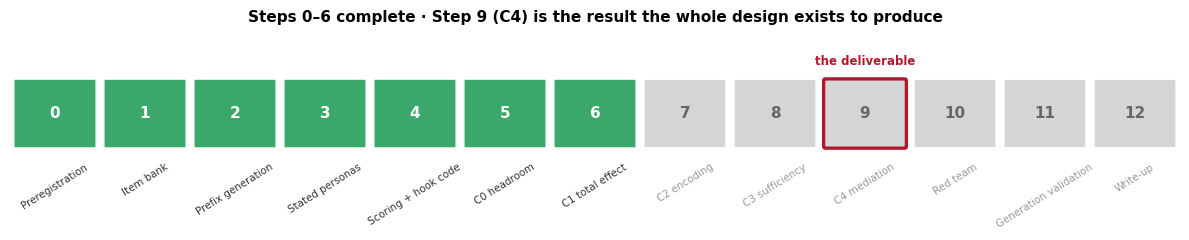

In [4]:
steps = [
    ("0", "Preregistration", "done"), ("1", "Item bank", "done"),
    ("2", "Prefix generation", "done"), ("3", "Stated personas", "done"),
    ("4", "Scoring + hook code", "done"), ("5", "C0 headroom", "done"),
    ("6", "C1 total effect", "done"), ("7", "C2 encoding", "todo"),
    ("8", "C3 sufficiency", "todo"), ("9", "C4 mediation", "todo"),
    ("10", "Red team", "todo"), ("11", "Generation validation", "todo"),
    ("12", "Write-up", "todo"),
]
colours = {"done": GREEN, "todo": "#d5d5d5"}

fig, ax = plt.subplots(figsize=(12, 2.5))
for i, (num, name, status) in enumerate(steps):
    ax.add_patch(FancyBboxPatch((i * 1.0 + 0.06, 0.45), 0.88, 0.62,
                                boxstyle="round,pad=0.02",
                                facecolor=colours[status], alpha=0.85 if status == "done" else 1,
                                edgecolor="white", linewidth=1.5))
    ax.text(i + 0.5, 0.76, num, ha="center", va="center", fontsize=11, fontweight="bold",
            color="white" if status == "done" else "#666")
    ax.text(i + 0.5, 0.30, name, ha="center", va="top", fontsize=7.4, rotation=32,
            color="#333" if status == "done" else "#999")

ax.add_patch(FancyBboxPatch((9.06, 0.45), 0.88, 0.62, boxstyle="round,pad=0.02",
                            facecolor="none", edgecolor=RED, linewidth=2.4))
ax.text(9.5, 1.22, "the deliverable", ha="center", fontsize=8.5, color=RED, fontweight="bold")
ax.set_xlim(0, 13); ax.set_ylim(-0.35, 1.5); ax.axis("off")
ax.set_title("Steps 0–6 complete · Step 9 (C4) is the result the whole design exists to produce", pad=10)
plt.tight_layout(); plt.show()

### The one-line summary of what has been established so far

- **Steps 0–4 (materials and tooling): all quality gates passed.** Notebook 02 has the evidence.
- **Step 5 (C0): the measure has headroom** — the model does prefer true answers to lures at
  baseline, so there is room for a manipulation to move it. One gate condition was amended, in the
  open, to get here.
- **Step 6 (C1): the primary manipulation produced a clean null.** Conversations that *behave*
  credulously do not move the model's answers at all. But an *explicitly stated* credulous persona
  **does** (`d_z` = 0.373, p = 5.9e-5).

That last finding is a genuine dissociation — **stated credulity works, inferred credulity does
not** — and it triggered the preregistered Plan B. Notebook 03 is where that evidence lives.